# Portal Homework Analysis

Use `homeworks.json` to analyze weekly homework workload, late submissions, and high-workload prediction.

## 0. Setup

Run this first. If packages are missing, install them in your terminal:

```bash
python -m pip install pandas matplotlib scikit-learn
```

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

WORKLOAD_ORDER = {"low": 0, "medium": 1, "high": 2}

def minmax(series):
    return series * 0 if series.max() == series.min() else (series - series.min()) / (series.max() - series.min())

def workload_level(value, low_cut, high_cut):
    if value <= low_cut:
        return "low"
    if value <= high_cut:
        return "medium"
    return "high"

## 1. Load data

In [2]:
json_path = "homeworks.json"

with open(json_path, "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

print("Total homework records:", len(df))
display(df.head())

Total homework records: 352


,semester,course_name,assignment_name,due_at,late_minutes,assignment_type,score
0,1142,作業系統概論,class Notes,2026/2/25 13:10,0,個人,100.0
1,1142,作業系統概論,class notes,2026/3/3 16:10,31,個人,0.0
2,1142,作業系統概論,class Notes,2026/3/4 12:10,0,個人,100.0
3,1142,作業系統概論,class notes,2026/3/10 16:15,0,個人,100.0
4,1142,作業系統概論,Class Notes,2026/3/11 12:30,0,個人,100.0


## 2. Clean data and create features

This notebook uses all assignment deadlines that already appeared in the portal dataset. Future assignments are kept for workload and deadline-pressure analysis because their due dates are already known. However, their late-submission status should be interpreted as "not recorded as late yet," not as final proof that the assignment was submitted on time.

In [3]:
df["due_at"] = pd.to_datetime(df["due_at"], errors="coerce")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["late_minutes"] = pd.to_numeric(df["late_minutes"], errors="coerce").fillna(0)

df = df.dropna(subset=["due_at"]).copy()

df["is_late"] = df["late_minutes"] > 0

df["has_score"] = df["score"].notna()
df["is_low_score"] = (df["score"].lt(80).where(df["has_score"], pd.NA).astype("boolean"))

df["due_date"] = df["due_at"].dt.date
df["due_year"] = df["due_at"].dt.year
df["due_month"] = df["due_at"].dt.month
df["due_week"] = df["due_at"].dt.isocalendar().week.astype("Int64")
df["due_weekday"] = df["due_at"].dt.day_name()
df["due_hour"] = df["due_at"].dt.hour

df["year_week"] = (df["due_year"].astype(str) + "-W" + df["due_week"].astype(str).str.zfill(2))

df["semester"] = df["semester"].astype(str)
df["course_name"] = df["course_name"].fillna("Unknown")
df["assignment_type"] = df["assignment_type"].fillna("Unknown")

print("Records after cleaning:", len(df))
print("Semesters:", sorted(df["semester"].unique()))
display(df.head())

Records after cleaning: 352
Semesters: ['1131', '1132', '1141', '1142']


,semester,course_name,assignment_name,due_at,late_minutes,assignment_type,score,is_late,has_score,is_low_score,due_date,due_year,due_month,due_week,due_weekday,due_hour,year_week
0,1142,作業系統概論,class Notes,2026-02-25 13:10:00,0,個人,100.0,False,True,False,2026-02-25,2026,2,9,Wednesday,13,2026-W09
1,1142,作業系統概論,class notes,2026-03-03 16:10:00,31,個人,0.0,True,True,True,2026-03-03,2026,3,10,Tuesday,16,2026-W10
2,1142,作業系統概論,class Notes,2026-03-04 12:10:00,0,個人,100.0,False,True,False,2026-03-04,2026,3,10,Wednesday,12,2026-W10
3,1142,作業系統概論,class notes,2026-03-10 16:15:00,0,個人,100.0,False,True,False,2026-03-10,2026,3,11,Tuesday,16,2026-W11
4,1142,作業系統概論,Class Notes,2026-03-11 12:30:00,0,個人,100.0,False,True,False,2026-03-11,2026,3,11,Wednesday,12,2026-W11


In [4]:
positive_late = df.loc[df["late_minutes"] > 0, "late_minutes"]

if len(positive_late) > 0:
    q1 = positive_late.quantile(0.25)
    q3 = positive_late.quantile(0.75)
    iqr = q3 - q1
    late_outlier_threshold = q3 + 1.5 * iqr

    df["is_late_outlier"] = df["late_minutes"] > late_outlier_threshold
    df["late_minutes_capped"] = df["late_minutes"].clip(
        upper=late_outlier_threshold
    )

    print("Late outlier threshold:", late_outlier_threshold)
    print("Number of late outliers:", df["is_late_outlier"].sum())

    display(
        df.loc[
            df["is_late_outlier"],
            [
                "semester",
                "course_name",
                "assignment_name",
                "due_at",
                "late_minutes",
                "late_minutes_capped",
            ],
        ]
        .sort_values("late_minutes", ascending=False)
    )

else:
    late_outlier_threshold = 0
    df["is_late_outlier"] = False
    df["late_minutes_capped"] = df["late_minutes"]

    print("No late submissions found. No late-minute outliers detected.")

Late outlier threshold: 10893.0
Number of late outliers: 8


,semester,course_name,assignment_name,due_at,late_minutes,late_minutes_capped
308,1132,程式設計（二）,Homework 1,2025-03-10 23:59:00,100556,10893
332,1131,華語（一）,Assignment 5: read aloud-d.t an.en,2024-11-27 23:59:00,60141,10893
178,1131,程式設計(一),As described on 20241021...,2024-10-21 23:59:00,35966,10893
229,1142,資料探勘,the three modules of data mining techniques,2026-03-09 23:59:00,20084,10893
129,1132,英語（二）：中階英語,Post your vote for Week 17,2025-03-05 23:59:00,16483,10893
273,1141,微積分（一）,Assignment,2025-12-30 23:59:00,12515,10893
344,1131,微積分（一）,Assignment,2025-12-30 23:59:00,12515,10893
150,1132,程式設計（二）,Homework 2,2025-03-31 23:59:00,12167,10893


## 3. Dataset overview

In [5]:
overview = pd.DataFrame({
    "metric": [
        "Total homework records",
        "Total semesters",
        "Total courses",
        "Overall late rate",
        "Average score",
        "Assignments with score",
    ],
    "value": [
        len(df),
        df["semester"].nunique(),
        df["course_name"].nunique(),
        f"{df['is_late'].mean():.2%}",
        round(df["score"].mean(), 2),
        df["score"].notna().sum(),
    ],
})

display(overview)

,metric,value
0,Total homework records,352
1,Total semesters,4
2,Total courses,31
3,Overall late rate,23.01%
4,Average score,72.22
5,Assignments with score,207


## 4. Research Question 1: Weekly workload

Q: How does homework workload change across academic weeks and semesters?

In [6]:
weekly_summary = (
    df.groupby(["semester", "year_week"], dropna=False)
    .agg(
        homework_count=("assignment_name", "count"),
        late_count=("is_late", "sum"),
        avg_late_minutes=("late_minutes_capped", "mean"),
        avg_score=("score", "mean"),
        scored_count=("has_score", "sum"),
        low_score_count=("is_low_score", "sum"),
    )
    .reset_index()
)

weekly_summary["late_rate"] = weekly_summary["late_count"] / weekly_summary["homework_count"]
weekly_summary["low_score_rate"] = np.where(
    weekly_summary["scored_count"] > 0,
    weekly_summary["low_score_count"] / weekly_summary["scored_count"],
    np.nan,
)

display(weekly_summary.head())

,semester,year_week,homework_count,late_count,avg_late_minutes,avg_score,scored_count,low_score_count,late_rate,low_score_rate
0,1131,2024-W37,1,1,621.00,NaN,0,0,1.00,NaN
1,1131,2024-W38,1,0,0.00,NaN,0,0,0.00,NaN
2,1131,2024-W40,3,0,0.00,100.0,2,0,0.00,0.0
3,1131,2024-W41,3,0,0.00,100.0,2,0,0.00,0.0
4,1131,2024-W42,4,1,196.75,100.0,2,0,0.25,0.0


In [7]:
q33 = weekly_summary["homework_count"].quantile(0.33)
q66 = weekly_summary["homework_count"].quantile(0.66)

weekly_summary["rule_workload_level"] = weekly_summary["homework_count"].apply(
    lambda count: workload_level(count, q33, q66)
)

weekly_summary["homework_count_norm"] = minmax(weekly_summary["homework_count"])
weekly_summary["late_rate_norm"] = minmax(weekly_summary["late_rate"].fillna(0))
weekly_summary["avg_late_minutes_norm"] = minmax(weekly_summary["avg_late_minutes"].fillna(0))
weekly_summary["weighted_workload_score"] = (
    0.60 * weekly_summary["homework_count_norm"] + 0.25 * weekly_summary["late_rate_norm"] + 0.15 * weekly_summary["avg_late_minutes_norm"]
) * 100
weekly_summary["weighted_workload_level"] = weekly_summary["weighted_workload_score"].apply(
    lambda score: "low" if score < 40 else "medium" if score < 60 else "high"
)

display(
    weekly_summary[
        [
            "semester",
            "year_week",
            "homework_count",
            "late_rate",
            "avg_late_minutes",
            "rule_workload_level",
            "weighted_workload_score",
            "weighted_workload_level",
        ]
    ].sort_values("homework_count", ascending=False).head(20)
)

,semester,year_week,homework_count,late_rate,avg_late_minutes,rule_workload_level,weighted_workload_score,weighted_workload_level
60,1142,2026-W11,15,0.133333,872.600000,high,65.736528,high
62,1142,2026-W13,14,0.071429,322.000000,high,58.386808,medium
69,1142,2026-W20,13,0.230769,4.230769,high,57.209454,medium
63,1142,2026-W14,13,0.307692,972.384615,high,61.798887,high
64,1142,2026-W15,12,0.333333,176.416667,high,55.962053,medium
68,1142,2026-W19,12,0.250000,26.833333,high,53.466758,medium
61,1142,2026-W12,11,0.090909,2.727273,high,45.137381,medium
13,1131,2024-W51,10,0.000000,0.000000,high,38.571429,low
71,1142,2026-W22,10,0.100000,40.700000,high,41.183519,medium
70,1142,2026-W21,10,0.100000,722.800000,high,43.062065,medium


K-Means silhouette score: 0.32061321782732377


,semester,year_week,homework_count,late_count,late_rate,avg_late_minutes,low_score_rate,kmeans_pattern_group
60,1142,2026-W11,15,2,0.133333,872.600000,0.222222,high assignment-count
62,1142,2026-W13,14,1,0.071429,322.000000,0.300000,high assignment-count
69,1142,2026-W20,13,3,0.230769,4.230769,0.666667,high assignment-count
63,1142,2026-W14,13,4,0.307692,972.384615,0.250000,high assignment-count
64,1142,2026-W15,12,4,0.333333,176.416667,0.000000,high assignment-count
68,1142,2026-W19,12,3,0.250000,26.833333,0.666667,high assignment-count
61,1142,2026-W12,11,1,0.090909,2.727273,0.250000,high assignment-count
13,1131,2024-W51,10,0,0.000000,0.000000,0.333333,medium assignment-count
71,1142,2026-W22,10,1,0.100000,40.700000,0.000000,high assignment-count
70,1142,2026-W21,10,1,0.100000,722.800000,0.000000,high assignment-count


,kmeans_pattern_group,week_count,avg_homework_count,avg_late_rate,avg_late_minutes,avg_low_score_rate
1,low assignment-count,19,2.315789,0.708772,2402.587719,0.157018
2,medium assignment-count,38,3.526316,0.087281,100.853947,0.254386
0,high assignment-count,19,9.157895,0.288806,578.227350,0.255556


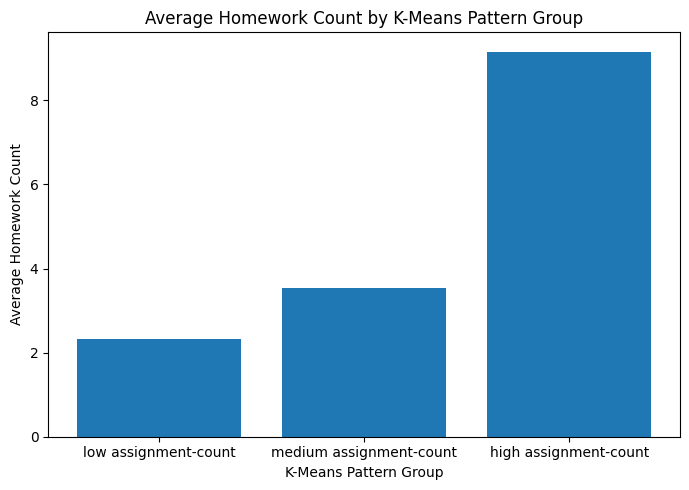

In [8]:
cluster_features = [
    "homework_count",
    "late_count",
    "late_rate",
    "avg_late_minutes",
    "low_score_rate",
]

cluster_data = weekly_summary.copy()
cluster_data[cluster_features] = cluster_data[cluster_features].fillna(0)
X_cluster = StandardScaler().fit_transform(cluster_data[cluster_features])

cluster_data["cluster"] = KMeans(n_clusters=3, random_state=123, n_init=10).fit_predict(X_cluster)
sil_score = silhouette_score(X_cluster, cluster_data["cluster"]) if len(cluster_data) > 3 and cluster_data["cluster"].nunique() > 1 else None

cluster_order = cluster_data.groupby("cluster")["homework_count"].mean().sort_values().index.tolist()
cluster_data["kmeans_pattern_group"] = cluster_data["cluster"].map(
    dict(
        zip(
            cluster_order,
            ["low assignment-count", "medium assignment-count", "high assignment-count"]
        )
    )
)

weekly_summary = weekly_summary.drop(columns=["cluster", "kmeans_pattern_group"], errors="ignore").merge(
    cluster_data[["semester", "year_week", "cluster", "kmeans_pattern_group"]],
    on=["semester", "year_week"],
    how="left",
)

print("K-Means silhouette score:", sil_score)
display(
    weekly_summary[
        [
            "semester",
            "year_week",
            "homework_count",
            "late_count",
            "late_rate",
            "avg_late_minutes",
            "low_score_rate",
            "kmeans_pattern_group",
        ]
    ].sort_values("homework_count", ascending=False).head(20)
)

cluster_profile = (
    cluster_data.groupby("kmeans_pattern_group")
    .agg(
        week_count=("year_week", "count"),
        avg_homework_count=("homework_count", "mean"),
        avg_late_rate=("late_rate", "mean"),
        avg_late_minutes=("avg_late_minutes", "mean"),
        avg_low_score_rate=("low_score_rate", "mean"),
    )
    .reset_index()
)
cluster_profile["order"] = cluster_profile["kmeans_pattern_group"].map(
    {
        "low assignment-count": 0,
        "medium assignment-count": 1,
        "high assignment-count": 2,
    }
)
cluster_profile = cluster_profile.sort_values("order").drop(columns="order")

display(cluster_profile)

plt.figure(figsize=(7, 5))
plt.bar(cluster_profile["kmeans_pattern_group"], cluster_profile["avg_homework_count"])
plt.xlabel("K-Means Pattern Group")
plt.ylabel("Average Homework Count")
plt.title("Average Homework Count by K-Means Pattern Group")
plt.tight_layout()
plt.show()

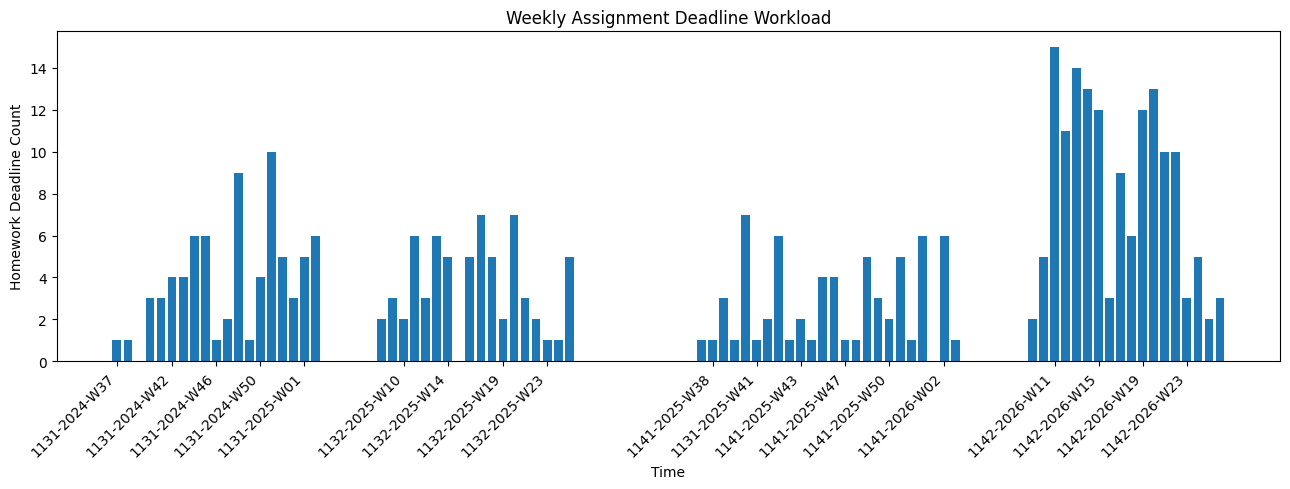

,semester,year_week,homework_count,late_count,late_rate,avg_late_minutes,rule_workload_level,weighted_workload_level,kmeans_pattern_group
60,1142,2026-W11,15,2,0.133333,872.600000,high,high,high assignment-count
62,1142,2026-W13,14,1,0.071429,322.000000,high,medium,high assignment-count
69,1142,2026-W20,13,3,0.230769,4.230769,high,medium,high assignment-count
63,1142,2026-W14,13,4,0.307692,972.384615,high,high,high assignment-count
64,1142,2026-W15,12,4,0.333333,176.416667,high,medium,high assignment-count
68,1142,2026-W19,12,3,0.250000,26.833333,high,medium,high assignment-count
61,1142,2026-W12,11,1,0.090909,2.727273,high,medium,high assignment-count
13,1131,2024-W51,10,0,0.000000,0.000000,high,low,medium assignment-count
71,1142,2026-W22,10,1,0.100000,40.700000,high,medium,high assignment-count
70,1142,2026-W21,10,1,0.100000,722.800000,high,medium,high assignment-count


In [9]:
weekly_plot = weekly_summary.copy()
weekly_plot[["iso_year", "iso_week"]] = weekly_plot["year_week"].str.extract(r"(\d{4})-W(\d+)").astype(int)
weekly_plot["week_start"] = pd.to_datetime(
    weekly_plot["iso_year"].astype(str) + "-W" + weekly_plot["iso_week"].astype(str).str.zfill(2) + "-1",
    format="%G-W%V-%u",
)
weekly_plot = weekly_plot.sort_values("week_start").copy()

full_plot = pd.DataFrame({
    "week_start": pd.date_range(weekly_plot["week_start"].min(), weekly_plot["week_start"].max(), freq="W-MON")
}).merge(
    weekly_plot[["week_start", "semester", "year_week", "homework_count"]],
    on="week_start",
    how="left",
)

full_plot["homework_count"] = full_plot["homework_count"].fillna(0).astype(int)
iso = full_plot["week_start"].dt.isocalendar()
full_plot["year_week"] = iso["year"].astype(str) + "-W" + iso["week"].astype(str).str.zfill(2)
full_plot["semester"] = full_plot["semester"].fillna("")
full_plot["label"] = ""
full_plot.loc[full_plot["homework_count"] > 0, "label"] = (
    full_plot.loc[full_plot["homework_count"] > 0, "semester"].astype(str) + "-" + full_plot.loc[full_plot["homework_count"] > 0, "year_week"]
)

nonzero_positions = full_plot.index[full_plot["homework_count"] > 0].tolist()
shown_positions = nonzero_positions[::4]

plt.figure(figsize=(13, 5))
plt.bar(full_plot.index, full_plot["homework_count"])
plt.xticks(ticks=shown_positions, labels=full_plot.loc[shown_positions, "label"], rotation=45, ha="right")
plt.xlabel("Time")
plt.ylabel("Homework Deadline Count")
plt.title("Weekly Assignment Deadline Workload")
plt.tight_layout()
plt.show()

display(
    weekly_summary.sort_values("homework_count", ascending=False).head(20)[
        [
            "semester",
            "year_week",
            "homework_count",
            "late_count",
            "late_rate",
            "avg_late_minutes",
            "rule_workload_level",
            "weighted_workload_level",
            "kmeans_pattern_group",
        ]
    ]
)

## 5. Research Question 2: Workload and late submissions

Q: Are high-workload weeks associated with more late submissions?

This section analyzes the relationship between weekly deadline workload and recorded late submissions. Since some future assignments are included as known deadlines, late rates are based on the current dataset records and should be interpreted as observed late-submission patterns, not final semester outcomes.

Correlation between homework_count and late_rate: -0.2582828879135779


,rule_workload_level,week_count,avg_homework_count,avg_late_rate,avg_late_minutes,avg_score
1,low,26,1.384615,0.442308,1046.500000,64.187500
2,medium,26,3.961538,0.232692,903.716026,78.681818
0,high,24,8.875000,0.196693,406.763318,72.350116


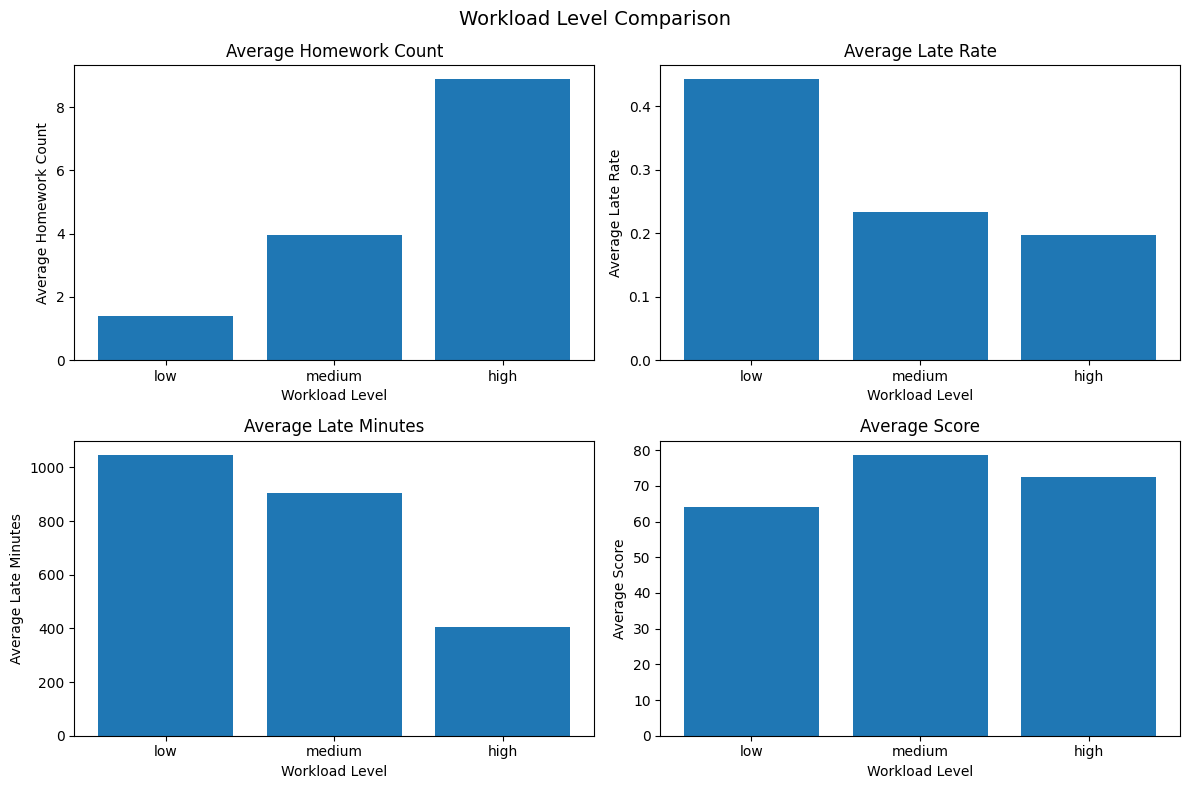

In [10]:
workload_late_summary = (
    weekly_summary.groupby("rule_workload_level")
    .agg(
        week_count=("year_week", "count"),
        avg_homework_count=("homework_count", "mean"),
        avg_late_rate=("late_rate", "mean"),
        avg_late_minutes=("avg_late_minutes", "mean"),
        avg_score=("avg_score", "mean"),
    )
    .reset_index()
)
workload_late_summary["level_order"] = workload_late_summary["rule_workload_level"].map(WORKLOAD_ORDER)
workload_late_summary = workload_late_summary.sort_values("level_order").drop(columns="level_order")

print("Correlation between homework_count and late_rate:", weekly_summary[["homework_count", "late_rate"]].corr().iloc[0, 1])
display(workload_late_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_settings = [
    ("avg_homework_count", "Average Homework Count", "Average Homework Count"),
    ("avg_late_rate", "Average Late Rate", "Average Late Rate"),
    ("avg_late_minutes", "Average Late Minutes", "Average Late Minutes"),
    ("avg_score", "Average Score", "Average Score"),
]

for ax, (column, title, ylabel) in zip(axes.ravel(), plot_settings):
    ax.bar(workload_late_summary["rule_workload_level"], workload_late_summary[column])
    ax.set_title(title)
    ax.set_xlabel("Workload Level")
    ax.set_ylabel(ylabel)

plt.suptitle("Workload Level Comparison", fontsize=14)
plt.tight_layout()
plt.show()

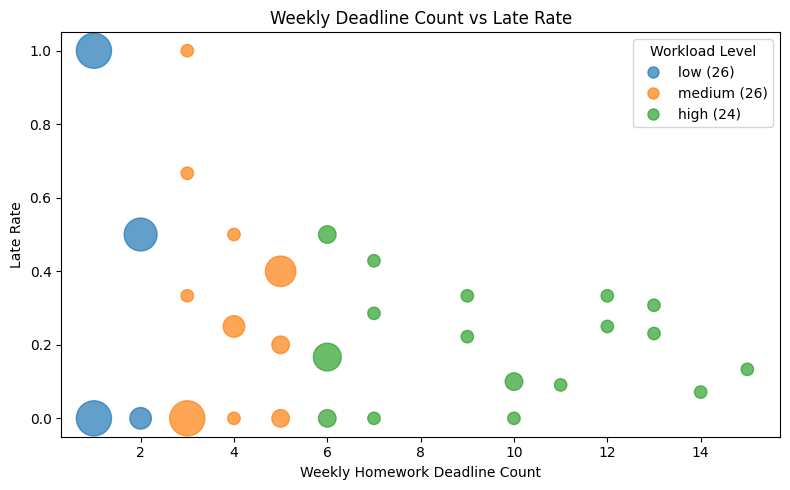

In [11]:
plot_data = (
    weekly_summary.groupby(["homework_count", "late_rate", "rule_workload_level"]).agg(week_count=("year_week", "count")).reset_index()
)

plt.figure(figsize=(8, 5))
handles = []

for level in ["low", "medium", "high"]:
    subset = plot_data[plot_data["rule_workload_level"] == level]
    scatter = plt.scatter(subset["homework_count"], subset["late_rate"], s=subset["week_count"] * 80, alpha=0.7)
    handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=8,
            label=f"{level} ({(weekly_summary['rule_workload_level'] == level).sum()})",
            markerfacecolor=scatter.get_facecolor()[0],
            markeredgecolor=scatter.get_facecolor()[0],
        )
    )

plt.xlabel("Weekly Homework Deadline Count")
plt.ylabel("Late Rate")
plt.title("Weekly Deadline Count vs Late Rate")
plt.legend(handles=handles, title="Workload Level")
plt.tight_layout()
plt.show()

## 6. Research Question 3: High-workload prediction

Q: Can calendar timing predict high-workload weeks?

In [12]:
weekly_model_source = weekly_summary.copy()
weekly_model_source[["iso_year", "iso_week"]] = weekly_model_source["year_week"].str.extract(r"(\d{4})-W(\d+)").astype(int)
weekly_model_source["week_start"] = pd.to_datetime(
    weekly_model_source["iso_year"].astype(str) + "-W" + weekly_model_source["iso_week"].astype(str).str.zfill(2) + "-1",
    format="%G-W%V-%u",
)
weekly_model_source["academic_year"] = weekly_model_source["semester"].str[:3].astype(int)
weekly_model_source["semester_term"] = weekly_model_source["semester"].str[-1]
weekly_model_source["semester_term_num"] = weekly_model_source["semester_term"].astype(int)

def get_semester_date_range(semester):
    academic_year = int(str(semester)[:3])
    semester_term = int(str(semester)[-1])
    start_year = academic_year + 1911

    if semester_term == 1:
        start_date = pd.Timestamp(start_year, 9, 1)
        end_date = pd.Timestamp(start_year + 1, 1, 31)
    else:
        start_date = pd.Timestamp(start_year + 1, 2, 1)
        end_date = pd.Timestamp(start_year + 1, 6, 30)

    return (
        start_date - pd.to_timedelta(start_date.weekday(), unit="D"),
        end_date - pd.to_timedelta(end_date.weekday(), unit="D"),
    )

weekly_model = pd.concat(
    [
        pd.DataFrame({"semester": semester, "week_start": pd.date_range(*get_semester_date_range(semester), freq="W-MON")})
        for semester in sorted(weekly_model_source["semester"].unique())
    ],
    ignore_index=True,
)

iso_calendar = weekly_model["week_start"].dt.isocalendar()
weekly_model["iso_year"] = iso_calendar.year.astype(int)
weekly_model["iso_week"] = iso_calendar.week.astype(int)
weekly_model["year_week"] = weekly_model["iso_year"].astype(str) + "-W" + weekly_model["iso_week"].astype(str).str.zfill(2)
weekly_model = weekly_model.merge(
    weekly_model_source.drop(columns=["iso_year", "iso_week", "week_start"]),
    on=["semester", "year_week"],
    how="left",
)

weekly_model["academic_year"] = weekly_model["semester"].str[:3].astype(int)
weekly_model["semester_term"] = weekly_model["semester"].str[-1]
weekly_model["semester_term_num"] = weekly_model["semester_term"].astype(int)

for col in [
    "homework_count",
    "late_count",
    "avg_late_minutes",
    "low_score_count",
    "late_rate",
    "low_score_rate",
    "homework_count_norm",
    "late_rate_norm",
    "avg_late_minutes_norm",
    "weighted_workload_score",
]:
    if col in weekly_model.columns:
        weekly_model[col] = weekly_model[col].fillna(0)

for col in ["rule_workload_level", "weighted_workload_level", "kmeans_pattern_group"]:
    if col in weekly_model.columns:
        weekly_model[col] = weekly_model[col].fillna("no_homework")

if "cluster" in weekly_model.columns:
    weekly_model["cluster"] = weekly_model["cluster"].fillna(-1)

weekly_model["has_homework"] = weekly_model["homework_count"] > 0
weekly_model["has_late_homework"] = weekly_model["late_count"] > 0
weekly_model["is_high_workload"] = weekly_model["homework_count"] >= 3
weekly_model["calendar_month"] = weekly_model["week_start"].dt.month
weekly_model["calendar_year"] = weekly_model["week_start"].dt.year
weekly_model["week_of_semester"] = weekly_model.sort_values(["semester", "week_start"]).groupby("semester").cumcount() + 1
weekly_model["week_of_academic_year"] = weekly_model.sort_values(["academic_year", "week_start"]).groupby("academic_year").cumcount() + 1
weekly_model["iso_week_sin"] = np.sin(2 * np.pi * weekly_model["iso_week"] / 53)
weekly_model["iso_week_cos"] = np.cos(2 * np.pi * weekly_model["iso_week"] / 53)
weekly_model = weekly_model.sort_values(["week_start", "semester"]).reset_index(drop=True)

print("Weekly modeling records:", len(weekly_model))
print("Academic years:", sorted(weekly_model["academic_year"].unique()))
print("Semesters:", sorted(weekly_model["semester"].unique()))
display(
    weekly_model[
        [
            "academic_year",
            "semester",
            "year_week",
            "week_start",
            "week_of_academic_year",
            "week_of_semester",
            "homework_count",
            "late_count",
            "is_high_workload",
        ]
    ].head(20)
)

Weekly modeling records: 91
Academic years: [np.int64(113), np.int64(114)]
Semesters: ['1131', '1132', '1141', '1142']


,academic_year,semester,year_week,week_start,week_of_academic_year,week_of_semester,homework_count,late_count,is_high_workload
0,113,1131,2024-W35,2024-08-26,1,1,0.0,0.0,False
1,113,1131,2024-W36,2024-09-02,2,2,0.0,0.0,False
2,113,1131,2024-W37,2024-09-09,3,3,1.0,1.0,False
3,113,1131,2024-W38,2024-09-16,4,4,1.0,0.0,False
4,113,1131,2024-W39,2024-09-23,5,5,0.0,0.0,False
5,113,1131,2024-W40,2024-09-30,6,6,3.0,0.0,True
6,113,1131,2024-W41,2024-10-07,7,7,3.0,0.0,True
7,113,1131,2024-W42,2024-10-14,8,8,4.0,1.0,True
8,113,1131,2024-W43,2024-10-21,9,9,4.0,1.0,True
9,113,1131,2024-W44,2024-10-28,10,10,6.0,1.0,True


In [13]:
train_academic_years = [113]
test_academic_years = [114]

q3_train_df = weekly_model[weekly_model["academic_year"].isin(train_academic_years)].copy()
q3_test_df = weekly_model[weekly_model["academic_year"].isin(test_academic_years)].copy()

print("Q3 training weekly records:", len(q3_train_df))
print("Q3 testing weekly records:", len(q3_test_df))
print("\nTraining high-workload rate:", f"{q3_train_df['is_high_workload'].mean():.2%}")
print("Testing high-workload rate:", f"{q3_test_df['is_high_workload'].mean():.2%}")
print("\nTraining high-workload True records:", int(q3_train_df["is_high_workload"].sum()))
print("Testing high-workload True records:", int(q3_test_df["is_high_workload"].sum()))

late_workload_summary = (
    q3_test_df.groupby("is_high_workload")
    .agg(
        weekly_records=("is_high_workload", "count"),
        avg_homework_count=("homework_count", "mean"),
        avg_late_count=("late_count", "mean"),
        avg_late_rate=("late_rate", "mean"),
    )
    .reset_index()
)

print("\nLate-submission pattern by workload type:")
display(late_workload_summary)

Q3 training weekly records: 46
Q3 testing weekly records: 45

Training high-workload rate: 50.00%
Testing high-workload rate: 57.78%

Training high-workload True records: 23
Testing high-workload True records: 26

Late-submission pattern by workload type:


,is_high_workload,weekly_records,avg_homework_count,avg_late_count,avg_late_rate
0,False,19,0.736842,0.263158,0.184211
1,True,26,7.423077,1.500000,0.216148


,target,model,TN,FP,FN,TP
0,is_high_workload,Logistic Regression,15,4,9,17
1,is_high_workload,Random Forest,12,7,6,20


,target,model,accuracy,precision,recall,f1_score,train_size,test_size
0,is_high_workload,Logistic Regression,0.711111,0.809524,0.653846,0.723404,46,45
1,is_high_workload,Random Forest,0.711111,0.740741,0.769231,0.754717,46,45


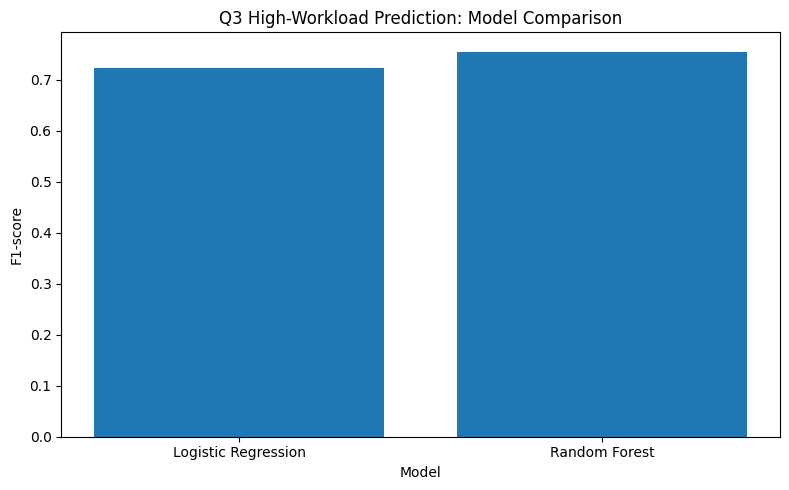

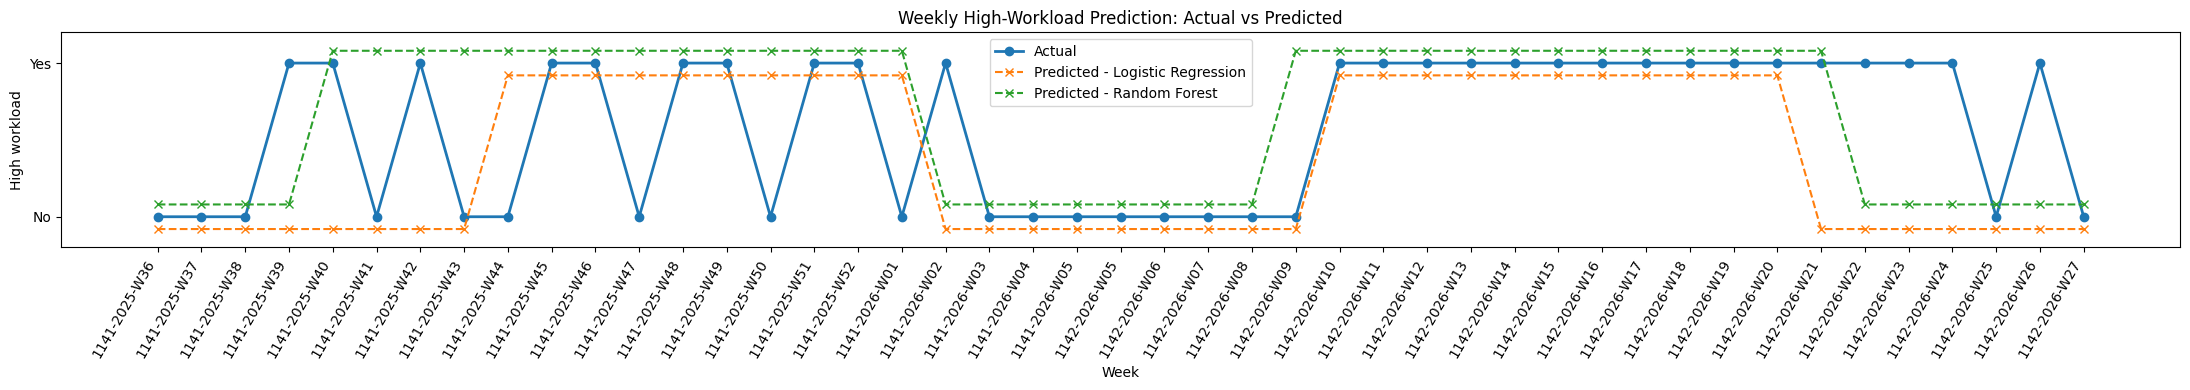

In [14]:
q3_feature_cols = [
    "semester_term_num",
    "calendar_month",
    "iso_week",
    "iso_week_sin",
    "iso_week_cos",
]

q3_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1,
        random_state=123,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=4,
        min_samples_split=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=123,
    ),
}

q3_target = "is_high_workload"

X_train_q3 = q3_train_df[q3_feature_cols]
X_test_q3 = q3_test_df[q3_feature_cols]
y_train_q3 = q3_train_df[q3_target]
y_test_q3 = q3_test_df[q3_target]

if y_train_q3.nunique() < 2:
    raise ValueError("Q3 training target has only one class. Cannot train classification models.")

q3_model_results = []
q3_confusion_results = []
q3_predictions = {}
q3_trained_pipelines = {}

for model_name, model in q3_models.items():
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train_q3, y_train_q3)
    y_pred_q3 = pipeline.predict(X_test_q3)

    tn, fp, fn, tp = confusion_matrix(y_test_q3, y_pred_q3).ravel()

    q3_model_results.append({
        "target": q3_target,
        "model": model_name,
        "accuracy": accuracy_score(y_test_q3, y_pred_q3),
        "precision": precision_score(y_test_q3, y_pred_q3, zero_division=0),
        "recall": recall_score(y_test_q3, y_pred_q3, zero_division=0),
        "f1_score": f1_score(y_test_q3, y_pred_q3, zero_division=0),
        "train_size": len(X_train_q3),
        "test_size": len(X_test_q3),
    })

    q3_confusion_results.append({
        "target": q3_target,
        "model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

    q3_predictions[model_name] = y_pred_q3
    q3_trained_pipelines[model_name] = pipeline

q3_confusion_results_df = pd.DataFrame(q3_confusion_results)
q3_model_results_df = pd.DataFrame(q3_model_results)

display(q3_confusion_results_df)
display(q3_model_results_df)

plt.figure(figsize=(8, 5))
plt.bar(q3_model_results_df["model"], q3_model_results_df["f1_score"])
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Q3 High-Workload Prediction: Model Comparison")
plt.tight_layout()
plt.show()

weekly_prediction_comparison_df = q3_test_df[
    [
        "academic_year",
        "semester",
        "year_week",
        "week_start",
        "week_of_academic_year",
        "week_of_semester",
        "homework_count",
        "late_count",
        "is_high_workload",
    ]
].copy()

weekly_prediction_comparison_df = weekly_prediction_comparison_df.rename(
    columns={
        "homework_count": "actual_homework_count",
        "late_count": "actual_late_count",
        "is_high_workload": "actual_is_high_workload",
    }
)

weekly_prediction_comparison_df["actual_is_high_workload_num"] = (
    weekly_prediction_comparison_df["actual_is_high_workload"].astype(int)
)

model_names = list(q3_predictions.keys())

for model_name in model_names:
    safe_model_name = model_name.lower().replace(" ", "_").replace("-", "_")

    weekly_prediction_comparison_df[f"predicted_{safe_model_name}"] = q3_predictions[model_name]

    weekly_prediction_comparison_df[f"predicted_{safe_model_name}_num"] = (
        weekly_prediction_comparison_df[f"predicted_{safe_model_name}"].astype(int)
    )

    weekly_prediction_comparison_df[f"{safe_model_name}_correct"] = (
        weekly_prediction_comparison_df[f"predicted_{safe_model_name}"]
        == weekly_prediction_comparison_df["actual_is_high_workload"]
    )

weekly_prediction_comparison_df = (
    weekly_prediction_comparison_df
    .sort_values(["week_start", "semester"])
    .reset_index(drop=True)
)

weekly_prediction_comparison_df["week_label"] = (
    weekly_prediction_comparison_df["semester"].astype(str)
    + "-"
    + weekly_prediction_comparison_df["year_week"].astype(str)
)

plt.figure(figsize=(22, 4))

x = np.arange(len(weekly_prediction_comparison_df))

plt.plot(
    x,
    weekly_prediction_comparison_df["actual_is_high_workload_num"],
    marker="o",
    linewidth=2,
    label="Actual"
)

offsets = np.linspace(-0.08, 0.08, len(model_names))

for model_name, offset in zip(model_names, offsets):
    safe_model_name = model_name.lower().replace(" ", "_").replace("-", "_")

    y_plot = (
        weekly_prediction_comparison_df[f"predicted_{safe_model_name}_num"]
        + offset
    )

    plt.plot(
        x,
        y_plot,
        marker="x",
        linestyle="--",
        label=f"Predicted - {model_name}"
    )

plt.title("Weekly High-Workload Prediction: Actual vs Predicted")
plt.xlabel("Week")
plt.ylabel("High workload")
plt.yticks([0, 1], ["No", "Yes"])
plt.xticks(
    x,
    weekly_prediction_comparison_df["week_label"],
    rotation=60,
    ha="right"
)
plt.ylim(-0.2, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

Best model for Q3:


,target,model,accuracy,precision,recall,f1_score,train_size,test_size
0,is_high_workload,Random Forest,0.711111,0.740741,0.769231,0.754717,46,45


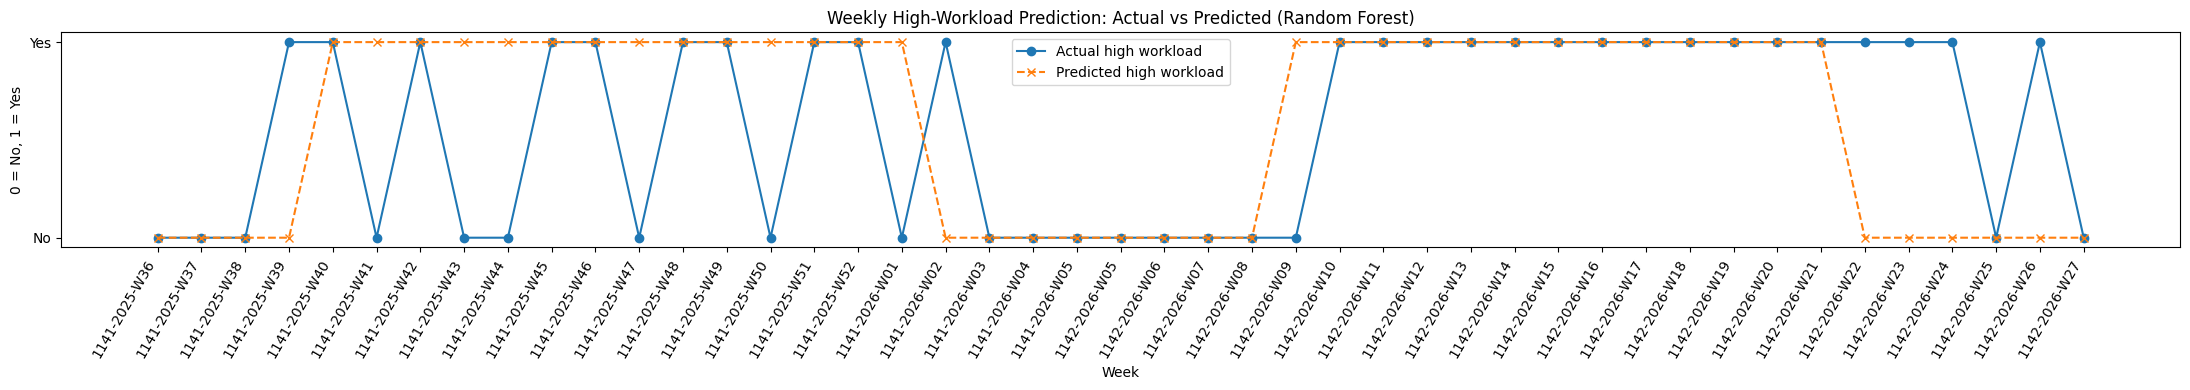

In [15]:
if q3_model_results_df.empty:
    raise ValueError("No Q3 model was trained. Please check whether the training target has at least two classes.")

best_model = q3_model_results_df.sort_values(["f1_score", "accuracy"], ascending=[False, False]).head(1).reset_index(drop=True)
best_model_name = best_model.loc[0, "model"]

print("Best model for Q3:")
display(best_model[["target", "model", "accuracy", "precision", "recall", "f1_score", "train_size", "test_size"]])

weekly_prediction_comparison_df = q3_test_df[
    [
        "academic_year",
        "semester",
        "year_week",
        "week_start",
        "week_of_academic_year",
        "week_of_semester",
        "homework_count",
        "late_count",
        "is_high_workload",
    ]
].copy()
weekly_prediction_comparison_df = weekly_prediction_comparison_df.rename(
    columns={
        "homework_count": "actual_homework_count",
        "late_count": "actual_late_count",
        "is_high_workload": "actual_is_high_workload",
    }
)
weekly_prediction_comparison_df["predicted_is_high_workload"] = q3_predictions[best_model_name]
weekly_prediction_comparison_df["high_workload_prediction_correct"] = (
    weekly_prediction_comparison_df["predicted_is_high_workload"] == weekly_prediction_comparison_df["actual_is_high_workload"]
)
weekly_prediction_comparison_df = weekly_prediction_comparison_df.sort_values(["week_start", "semester"]).reset_index(drop=True)
weekly_prediction_comparison_df["week_label"] = weekly_prediction_comparison_df["semester"].astype(str) + "-" + weekly_prediction_comparison_df["year_week"].astype(str)
weekly_prediction_comparison_df["actual_is_high_workload_num"] = weekly_prediction_comparison_df["actual_is_high_workload"].astype(int)
weekly_prediction_comparison_df["predicted_is_high_workload_num"] = weekly_prediction_comparison_df["predicted_is_high_workload"].astype(int)

plt.figure(figsize=(22, 4))
plt.plot(weekly_prediction_comparison_df["week_label"], weekly_prediction_comparison_df["actual_is_high_workload_num"], marker="o", label="Actual high workload")
plt.plot(weekly_prediction_comparison_df["week_label"], weekly_prediction_comparison_df["predicted_is_high_workload_num"], marker="x", linestyle="--", label="Predicted high workload")
plt.title(f"Weekly High-Workload Prediction: Actual vs Predicted ({best_model_name})")
plt.xlabel("Week")
plt.ylabel("0 = No, 1 = Yes")
plt.yticks([0, 1], ["No", "Yes"])
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()